Thredds Server for Doppio: https://tds.marine.rutgers.edu/thredds/catalog/roms/doppio/2017_da/avg/runs/catalog.html

Github Repository: https://github.com/salaimo26/ara101_may26

In [ ]:
import xarray as xr 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cartopy.crs import PlateCarree 
import cartopy.crs as ccrs
import matplotlib as mpl

In [3]:
url = "https://tds.marine.rutgers.edu/thredds/dodsC/roms/doppio/2017_da/avg/runs/Averages_RUN_2026-05-05T00:00:00Z" ## This is the Doppio Future Cast--> need to change the date to get the most recent run 
ds = xr.open_dataset(url,chunks={"ocean_time": 1},  decode_times=True)

In [12]:
run_date = pd.to_datetime(ds.time1[0].values).strftime("%Y-%m-%d")

In [5]:
ds

<xarray.Dataset> Size: 361MB
Dimensions:         (s_rho: 40, s_w: 41, eta_rho: 106, xi_rho: 242, eta_u: 106,
                     xi_u: 241, eta_v: 105, xi_v: 242, eta_psi: 105,
                     xi_psi: 241, ocean_time: 1, time1: 6, time3: 6, tracer: 2,
                     boundary: 4)
Coordinates: (12/13)
  * s_rho           (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * s_w             (s_w) float64 328B -1.0 -0.975 -0.95 ... -0.05 -0.025 0.0
    lon_rho         (eta_rho, xi_rho) float64 205kB dask.array<chunksize=(106, 242), meta=np.ndarray>
    lat_rho         (eta_rho, xi_rho) float64 205kB dask.array<chunksize=(106, 242), meta=np.ndarray>
    lon_u           (eta_u, xi_u) float64 204kB dask.array<chunksize=(106, 241), meta=np.ndarray>
    lat_u           (eta_u, xi_u) float64 204kB dask.array<chunksize=(106, 241), meta=np.ndarray>
    ...              ...
    lat_v           (eta_v, xi_v) float64 203kB dask.array<chunksize=(105, 242), meta=np.ndarray>
    lon_psi         (eta_psi, xi_psi) float64 202kB dask.array<chunksize=(105, 241), meta=np.ndarray>
    lat_psi         (eta_psi, xi_psi) float64 202kB dask.array<chunksize=(105, 241), meta=np.ndarray>
  * ocean_time      (ocean_time) datetime64[ns] 8B 2026-03-31T12:00:00
  * time1           (time1) datetime64[ns] 48B 2026-05-05T12:00:00 ... 2026-0...
  * time3           (time3) datetime64[ns] 48B 2026-05-05T12:00:00 ... 2026-0...
Dimensions without coordinates: eta_rho, xi_rho, eta_u, xi_u, eta_v, xi_v,
                                eta_psi, xi_psi, tracer, boundary
Data variables: (12/109)
    time1_offset    (time1) datetime64[ns] 48B dask.array<chunksize=(6,), meta=np.ndarray>
    time3_offset    (time3) datetime64[ns] 48B dask.array<chunksize=(6,), meta=np.ndarray>
    ntimes          int32 4B ...
    ndtfast         int32 4B ...
    dt              float64 8B ...
    dtfast          float64 8B ...
    ...              ...
    salt            (time1, s_rho, eta_rho, xi_rho) float64 49MB dask.array<chunksize=(6, 40, 106, 242), meta=np.ndarray>
    shflux          (time1, eta_rho, xi_rho) float64 1MB dask.array<chunksize=(6, 106, 242), meta=np.ndarray>
    ssflux          (time1, eta_rho, xi_rho) float64 1MB dask.array<chunksize=(6, 106, 242), meta=np.ndarray>
    swrad_daily     (time3, eta_rho, xi_rho) float64 1MB dask.array<chunksize=(6, 106, 242), meta=np.ndarray>
    sustr           (time1, eta_u, xi_u) float64 1MB dask.array<chunksize=(6, 106, 241), meta=np.ndarray>
    svstr           (time1, eta_v, xi_v) float64 1MB dask.array<chunksize=(6, 105, 242), meta=np.ndarray>
Attributes: (12/46)
    file:                            doppio_avg_7392_0003.nc
    format:                          netCDF-4/HDF5 file
    Conventions:                     CF-1.4, SGRID-0.3
    type:                            ROMS/TOMS nonlinear model averages file
    title:                           ROMS doppio Real-Time Operational PSAS F...
    var_info:                        ../Data/varinfo1040t_daily.dat
    ...                              ...
    frc_file_07:                     ../Data/Winds_ncepnam_3hourly_MAB_and_Go...
    cdm_data_type:                   GRID
    featureType:                     GRID
    location:                        Proto fmrc:doppio_2017_da_avg
    summary:                         doppio
    DODS_EXTRA.Unlimited_Dimension:  ocean_time

In [16]:
### Creating a custom colorbar for a 12 deg C (54F) Squid Bridge Definition
bounds =np.arange(0,26,1)
cmap = plt.get_cmap("bwr", len(bounds)-1)  # discrete colors for each bin

colors = cmap(np.arange(cmap.N))
colors[12] = [1, 1, 1, 1,]  ## Making 12 deg C White

custom_cmap = mpl.colors.ListedColormap(colors)

norm = mpl.colors.BoundaryNorm(bounds, custom_cmap.N)

In [17]:
## Labels for our colorbar later
tick_labels_c = ['0.0',"","", '3.0',"","", '6.0', "","",'9.0', "","",'12.0', "","",'15.0',"","", '18.0', "","",'21.0',"","","24.0°C"]
tick_labels_f = ['32.0',"","", '37.4',"","", '42.8', "","",'48.2', "","",'53.6', "","",'59.0',"","", '64.4', "","",'69.8',"","","75.2°F"]

In [ ]:
## Bathymetry from local file 
bathy_levels = [-200,-100,-50,-25]

bathy_path = "bathymetry_srtm15_v24_7551_5406_9ef5.nc"

etopo1 = xr.open_dataset(bathy_path)

In [32]:
etopo1

<xarray.Dataset> Size: 24MB
Dimensions:    (latitude: 2281, longitude: 2641)
Coordinates:
  * latitude   (latitude) float64 18kB 36.0 36.01 36.01 ... 45.49 45.5 45.5
  * longitude  (longitude) float64 21kB -77.0 -76.99 -76.99 ... -66.0 -66.0
Data variables:
    z          (latitude, longitude) float32 24MB ...
Attributes: (12/25)
    cdm_data_type:              Grid
    Conventions:                CF-1.7, COARDS, ACDD-1.3
    Easternmost_Easting:        -65.99791666666667
    geospatial_lat_max:         45.50208333333333
    geospatial_lat_min:         36.00208333333333
    geospatial_lat_resolution:  0.004166666666666667
    ...                         ...
    sourceUrl:                  (local files)
    Southernmost_Northing:      36.00208333333333
    standard_name_vocabulary:   CF Standard Name Table v70
    summary:                    Produced by grdmath. Data from a local source.
    title:                      SRTM15+: Global Bathymetry and Topgraphy at 1...
    Westernmost_Easting:        -76.99791666666667

#### Temperature

Text(0.4, 0.87, 'Sea Surface Temperature \n Doppio Future Cast')

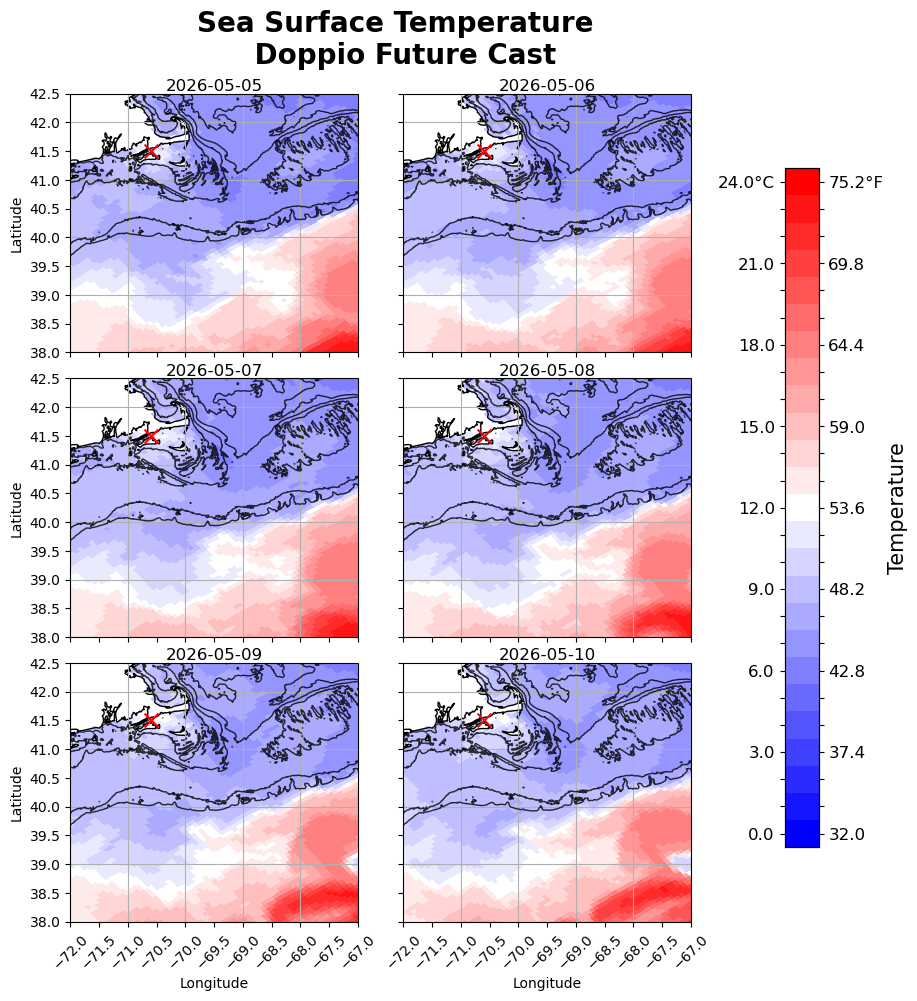

In [ ]:
## Surface
fig, ax = plt.subplots(3,2,figsize=(15,12),subplot_kw={"projection":PlateCarree()})
ax = ax.flatten()

extent = [-72, -67, 38, 42.5]

for i in range(6):
    ax[i].set_extent(extent)
    sst = ds.temp.isel(time1=i, s_rho=-1).plot(
        x='lon_rho',
        y='lat_rho',
        ax=ax[i],
        add_colorbar=False,
        cmap=custom_cmap,
        norm=norm
    )
    ax[i].set_xlabel('Longitude')
    ax[i].set_ylabel('Latitude')

    ax[i].set_title(f'{pd.to_datetime(ds.time1[i].values).strftime("%Y-%m-%d")}',pad=0.6)
    ax[i].coastlines()


## Adding the gridlines and ticks to each subplot
    ax[i].gridlines(crs=ccrs.PlateCarree(), draw_labels=False)

    ax[i].set_xticks(np.arange(extent[0],extent[1]+0.5, 0.5), crs=ccrs.PlateCarree())
    ax[i].set_yticks(np.arange(extent[2], extent[3]+0.5,0.5), crs=ccrs.PlateCarree())

    ax[i].tick_params(axis='x', labelsize=10,rotation=45)
    ax[i].tick_params(axis='y', labelsize=10)

    ## Adding the 25m, 50m and 100m Bathymetry Contours to each Subplot
    ax[i].contour(etopo1.longitude, etopo1.latitude, etopo1.z, bathy_levels, transform=ccrs.PlateCarree(), colors='black', linewidths=1,linestyles='solid', alpha=0.8, zorder=9)

    ax[i].label_outer() ## Only labeling the outer subplots for readability 

    ax[i].scatter(-70.6,41.5,marker="x",color='red',s=100,zorder=50)

fig.subplots_adjust(hspace=0.1, wspace=-0.1,top=0.8,right=0.75) ## Adjusting the plot to accomodate all subplots and the colorbar 

# ------ Custom CBar ------ #
cbar = fig.colorbar(sst, ax=ax,orientation="vertical", shrink=0.82,pad=0.1)
cbar.set_label("Temperature",fontsize=15,labelpad=50)

tick_locs = bounds[:-1] + 0.5 # This centers the label in the color box

cbar.set_ticks(tick_locs)
cbar.ax.minorticks_off()
cbar.set_ticklabels(tick_labels_c) ## Celcius Labels
cbar.ax.tick_params(labelsize=12)

# ------ Adding Farenheit to Cbar ------ #
cax2 = cbar.ax.twinx()
ticks = cbar.get_ticks()

cax2.set_ylim(cbar.ax.get_ylim())
cax2.set_yticks(ticks)

cax2.set_yticklabels(tick_labels_f)
cax2.tick_params(labelsize=12)

plt.suptitle("Sea Surface Temperature \n Doppio Future Cast", weight='bold',fontsize=20,x=0.4,y=0.87)

plt.savefig(f'doppio_future_{run_date}_surface_temp.png',dpi=150,bbox_inches='tight');


Text(0.4, 0.87, 'Bottom Temperature \n Doppio Future Cast')

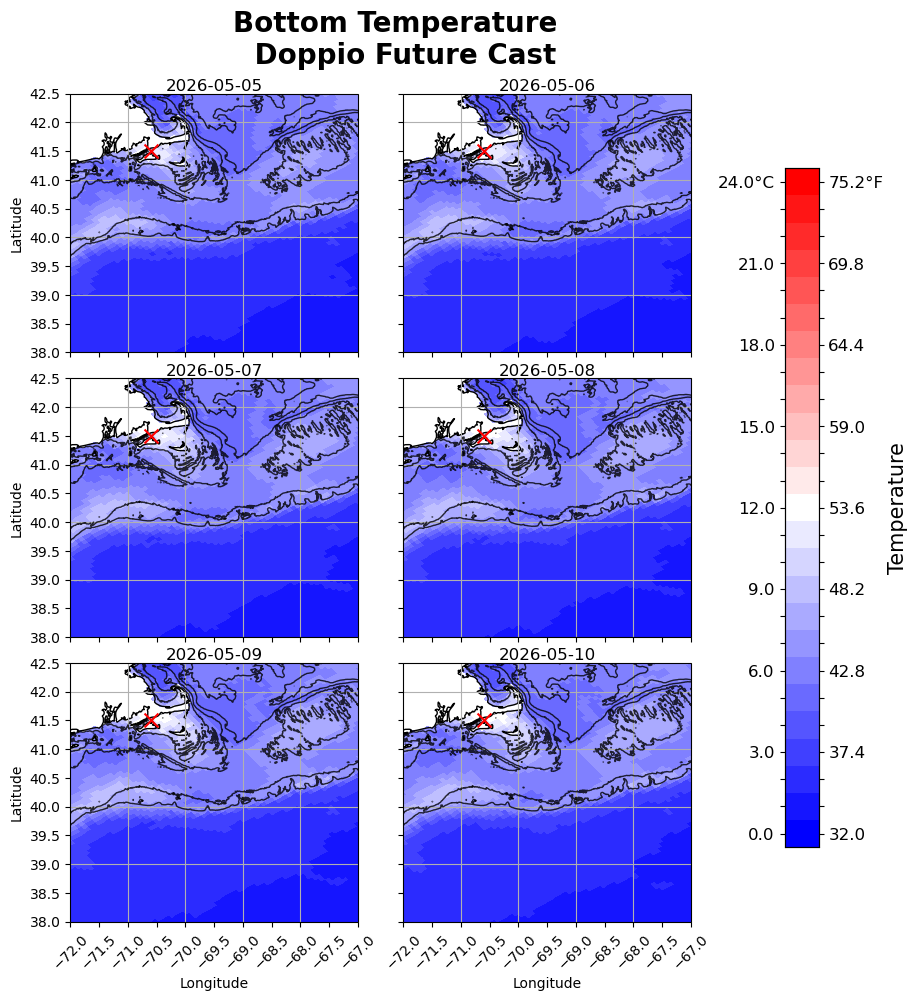

In [ ]:
## Bottom
fig, ax = plt.subplots(3,2,figsize=(15,12),subplot_kw={"projection":PlateCarree()})
ax = ax.flatten()

extent = [-72, -67, 38, 42.5]

for i in range(6):
    ax[i].set_extent(extent)
    sst = ds.temp.isel(time1=i, s_rho=0).plot(
        x='lon_rho',
        y='lat_rho',
        ax=ax[i],
        add_colorbar=False,
        cmap=custom_cmap,
        norm=norm
    )
    ax[i].set_xlabel('Longitude')
    ax[i].set_ylabel('Latitude')

    ax[i].set_title(f'{pd.to_datetime(ds.time1[i].values).strftime("%Y-%m-%d")}',pad=0.6)
    ax[i].coastlines()


## Adding the gridlines and ticks to each subplot
    ax[i].gridlines(crs=ccrs.PlateCarree(), draw_labels=False)

    ax[i].set_xticks(np.arange(extent[0],extent[1]+0.5, 0.5), crs=ccrs.PlateCarree())
    ax[i].set_yticks(np.arange(extent[2], extent[3]+0.5,0.5), crs=ccrs.PlateCarree())

    ax[i].tick_params(axis='x', labelsize=10,rotation=45)
    ax[i].tick_params(axis='y', labelsize=10)

    ## Adding the 25m, 50m and 100m Bathymetry Contours to each Subplot
    ax[i].contour(etopo1.longitude, etopo1.latitude, etopo1.z, bathy_levels, transform=ccrs.PlateCarree(), colors='black', linewidths=1,linestyles='solid', alpha=0.8, zorder=9)


    ax[i].label_outer() ## Only labeling the outer subplots for readability 

    ax[i].scatter(-70.6,41.5,marker="x",color='red',s=100,zorder=50)

fig.subplots_adjust(hspace=0.1, wspace=-0.1,top=0.8,right=0.75) ## Adjusting the plot to accomodate all subplots and the colorbar 

# ------ Custom CBar ------ #
cbar = fig.colorbar(sst, ax=ax,orientation="vertical", shrink=0.82,pad=0.1)
cbar.set_label("Temperature",fontsize=15,labelpad=50)

tick_locs = bounds[:-1] + 0.5 # This centers the label in the color box

cbar.set_ticks(tick_locs)
cbar.ax.minorticks_off()
cbar.set_ticklabels(tick_labels_c) ## Celcius Labels
cbar.ax.tick_params(labelsize=12)

# ------ Adding Farenheit to Cbar ------ #
cax2 = cbar.ax.twinx()
ticks = cbar.get_ticks()

cax2.set_ylim(cbar.ax.get_ylim())
cax2.set_yticks(ticks)

cax2.set_yticklabels(tick_labels_f)
cax2.tick_params(labelsize=12)

plt.suptitle("Bottom Temperature \n Doppio Future Cast", weight='bold',fontsize=20,x=0.4,y=0.87)

plt.savefig(f'doppio_future_{run_date}_bottom_temp.png',dpi=150,bbox_inches='tight');


#### Salinity

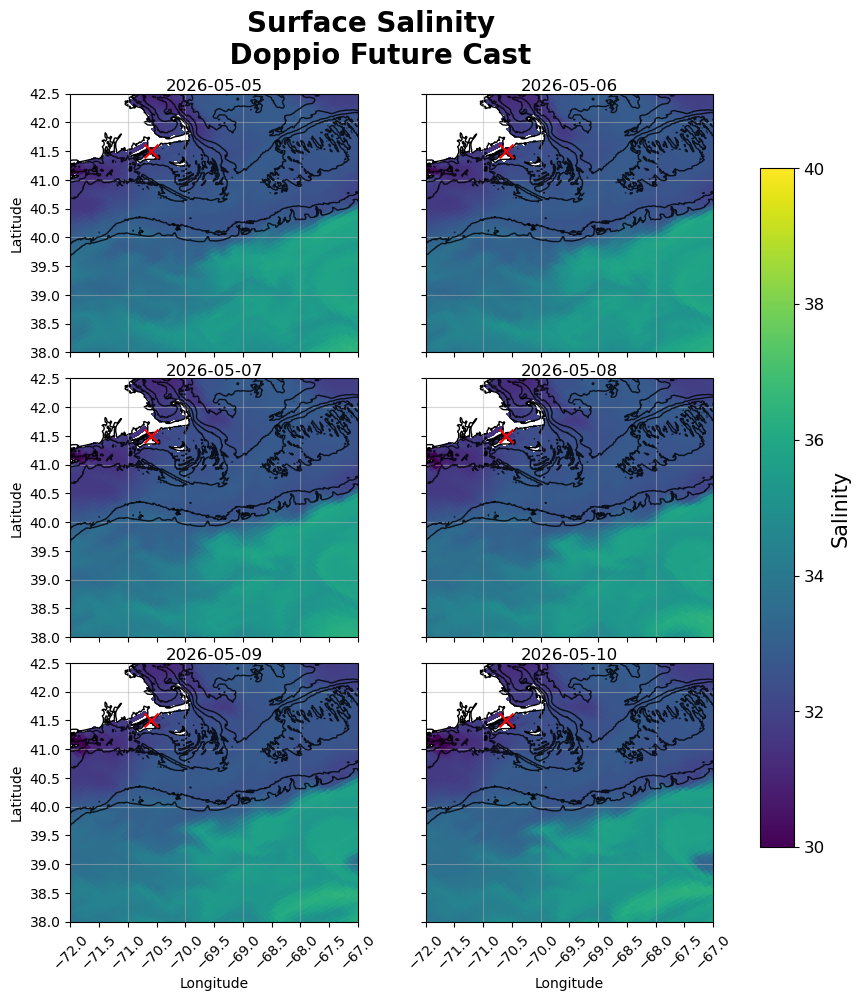

In [36]:
## Surface
fig, ax = plt.subplots(3,2,figsize=(15,12),subplot_kw={"projection":PlateCarree()})
ax = ax.flatten()

extent = [-72, -67, 38, 42.5]

for i in range(6):
    ax[i].set_extent(extent)
    sst = ds.salt.isel(time1=i, s_rho=-1).plot(
        x='lon_rho',
        y='lat_rho',
        ax=ax[i],
        add_colorbar=False,
        vmin=30, 
        vmax=40
    )
    ax[i].set_xlabel('Longitude')
    ax[i].set_ylabel('Latitude')

    ax[i].set_title(f'{pd.to_datetime(ds.time1[i].values).strftime("%Y-%m-%d")}',pad=0.6)
    ax[i].coastlines()


## Adding the gridlines and ticks to each subplot
    ax[i].gridlines(crs=ccrs.PlateCarree(), draw_labels=False,alpha=0.5)

    ax[i].set_xticks(np.arange(extent[0],extent[1]+0.5, 0.5), crs=ccrs.PlateCarree())
    ax[i].set_yticks(np.arange(extent[2], extent[3]+0.5,0.5), crs=ccrs.PlateCarree())

    ax[i].tick_params(axis='x', labelsize=10,rotation=45)
    ax[i].tick_params(axis='y', labelsize=10)

    ## Adding the 25m, 50m and 100m Bathymetry Contours to each Subplot
    ax[i].contour(etopo1.longitude, etopo1.latitude, etopo1.z, bathy_levels, transform=ccrs.PlateCarree(), colors='black', linewidths=1,linestyles='solid', alpha=0.8, zorder=9)


    ax[i].label_outer() ## Only labeling the outer subplots for readability 

    ax[i].scatter(-70.6,41.5,marker="x",color='red',s=100,zorder=50)

fig.subplots_adjust(hspace=0.1, wspace=-0.1,top=0.8,right=0.75) ## Adjusting the plot to accomodate all subplots and the colorbar 

# ------ Custom CBar ------ #
cbar = fig.colorbar(sst, ax=ax,orientation="vertical", shrink=0.82)
cbar.set_label("Salinity", fontsize=15)
cbar.set_ticks(ticks=np.arange(30,41,2),labels=np.arange(30,41,2),fontsize=12)

plt.suptitle("Surface Salinity \n Doppio Future Cast", weight='bold',fontsize=20,x=0.4,y=0.87)

plt.savefig(f'doppio_future_{run_date}_surface_salinity.png',dpi=150,bbox_inches='tight');


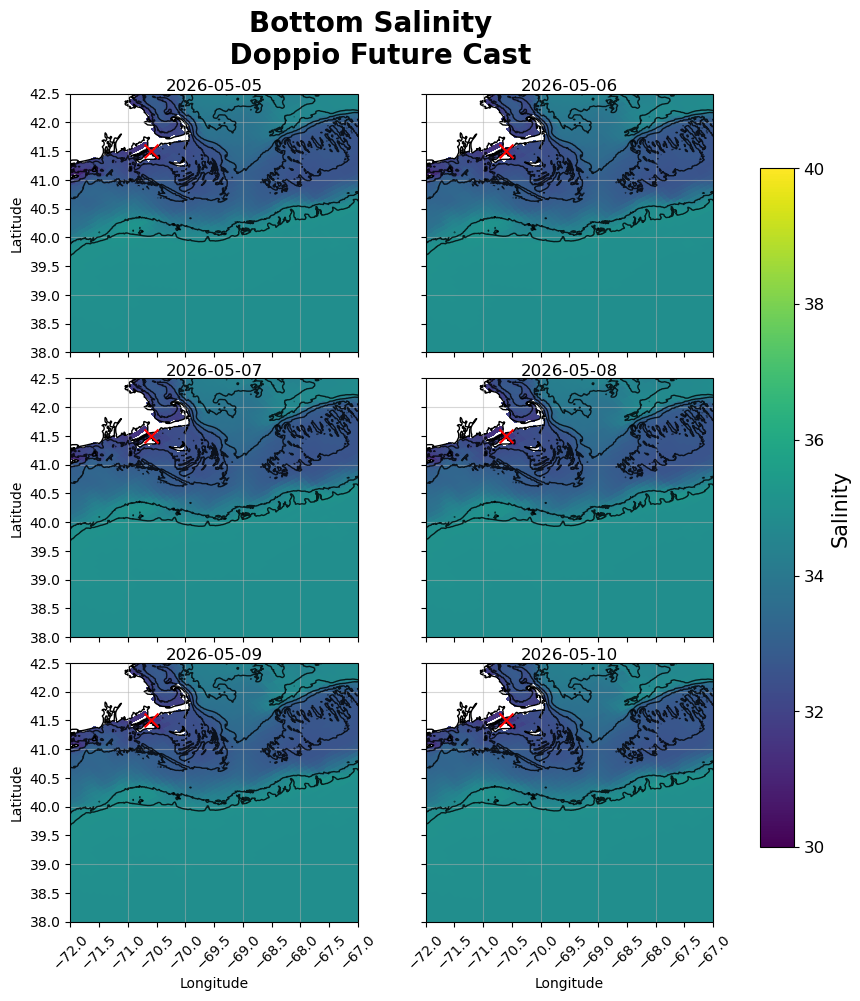

In [37]:
## Bottom
fig, ax = plt.subplots(3,2,figsize=(15,12),subplot_kw={"projection":PlateCarree()})
ax = ax.flatten()

extent = [-72, -67, 38, 42.5]

for i in range(6):
    ax[i].set_extent(extent)
    sst = ds.salt.isel(time1=i, s_rho=0).plot(
        x='lon_rho',
        y='lat_rho',
        ax=ax[i],
        add_colorbar=False,
        vmin=30, 
        vmax=40
    )
    ax[i].set_xlabel('Longitude')
    ax[i].set_ylabel('Latitude')

    ax[i].set_title(f'{pd.to_datetime(ds.time1[i].values).strftime("%Y-%m-%d")}',pad=0.6)
    ax[i].coastlines()


## Adding the gridlines and ticks to each subplot
    ax[i].gridlines(crs=ccrs.PlateCarree(), draw_labels=False,alpha=0.5)

    ax[i].set_xticks(np.arange(extent[0],extent[1]+0.5, 0.5), crs=ccrs.PlateCarree())
    ax[i].set_yticks(np.arange(extent[2], extent[3]+0.5,0.5), crs=ccrs.PlateCarree())

    ax[i].tick_params(axis='x', labelsize=10,rotation=45)
    ax[i].tick_params(axis='y', labelsize=10)

    ## Adding the 25m, 50m and 100m Bathymetry Contours to each Subplot
    ax[i].contour(etopo1.longitude, etopo1.latitude, etopo1.z, bathy_levels, transform=ccrs.PlateCarree(), colors='black', linewidths=1,linestyles='solid', alpha=0.8, zorder=9)

    ax[i].label_outer() ## Only labeling the outer subplots for readability 

    ax[i].scatter(-70.6,41.5,marker="x",color='red',s=100,zorder=50)

fig.subplots_adjust(hspace=0.1, wspace=-0.1,top=0.8,right=0.75) ## Adjusting the plot to accomodate all subplots and the colorbar 

# ------ Custom CBar ------ #
cbar = fig.colorbar(sst, ax=ax,orientation="vertical", shrink=0.82)
cbar.set_label("Salinity", fontsize=15)
cbar.set_ticks(ticks=np.arange(30,41,2),labels=np.arange(30,41,2),fontsize=12)

plt.suptitle("Bottom Salinity \n Doppio Future Cast", weight='bold',fontsize=20,x=0.4,y=0.87)

plt.savefig('doppio_future_05_04_26_bottom_salinity.png',dpi=150,bbox_inches='tight'); 

#### Profile at a Point 

In [22]:
lon_rho = ds['lon_rho']
lat_rho = ds['lat_rho']

target_lat = 40.0
target_lon = -70.0

# Find indices
abs_diff = np.abs(lon_rho.values - target_lon) + np.abs(lat_rho.values - target_lat)
j, i = np.unravel_index(np.argmin(abs_diff), lon_rho.shape)

subset_point = ds.isel(eta_rho=j, xi_rho=i)

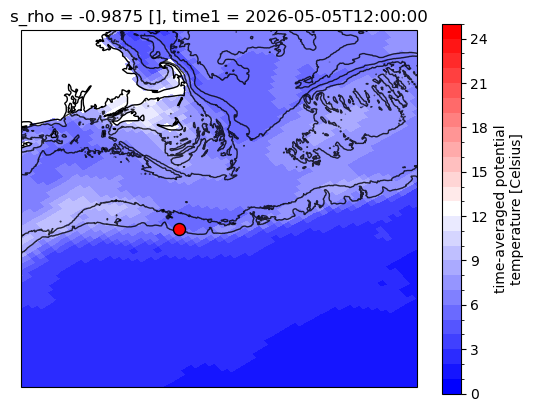

In [38]:
fig,ax= plt.subplots(subplot_kw={'projection':PlateCarree()})


ds.temp.isel(s_rho=0,time1=0).plot(x='lon_rho',y='lat_rho',cmap=custom_cmap,norm=norm)
ax.set_extent(extent)
ax.coastlines()
ax.contour(etopo1.longitude, etopo1.latitude, etopo1.z, bathy_levels, transform=ccrs.PlateCarree(), colors='black', linewidths=1,linestyles='solid', alpha=0.8, zorder=9)


ax.scatter(target_lon,target_lat,marker='.',s=300,color='red',edgecolors='k',zorder=10)

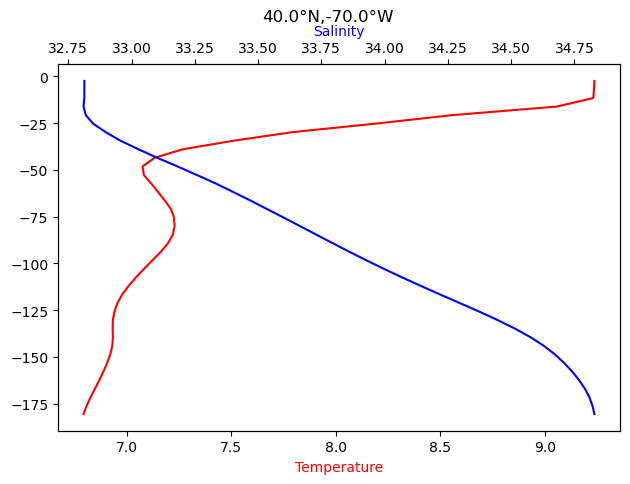

In [24]:
time_step = 5
dynamic_depth = subset_point.s_rho*subset_point.h+subset_point.zeta[time_step].values
fig, ax1 = plt.subplots()

# Primary Plot (Bottom X-Axis)
ax1.plot(subset_point['temp'][time_step],dynamic_depth, color='r', label='Temp')
ax1.set_xlabel('Temperature',color='r')

# Secondary Plot (Top X-Axis)
ax2 = ax1.twiny()
ax2.plot(subset_point['salt'][time_step],dynamic_depth, color='b', label='Sal')
ax2.set_xlabel('Salinity',color='b')

# fig.suptitle('NJ2 08-01-2024')
fig.tight_layout()

plt.suptitle(f'{target_lat}\u00B0N,{target_lon}\u00B0W',y=1,x=0.52);

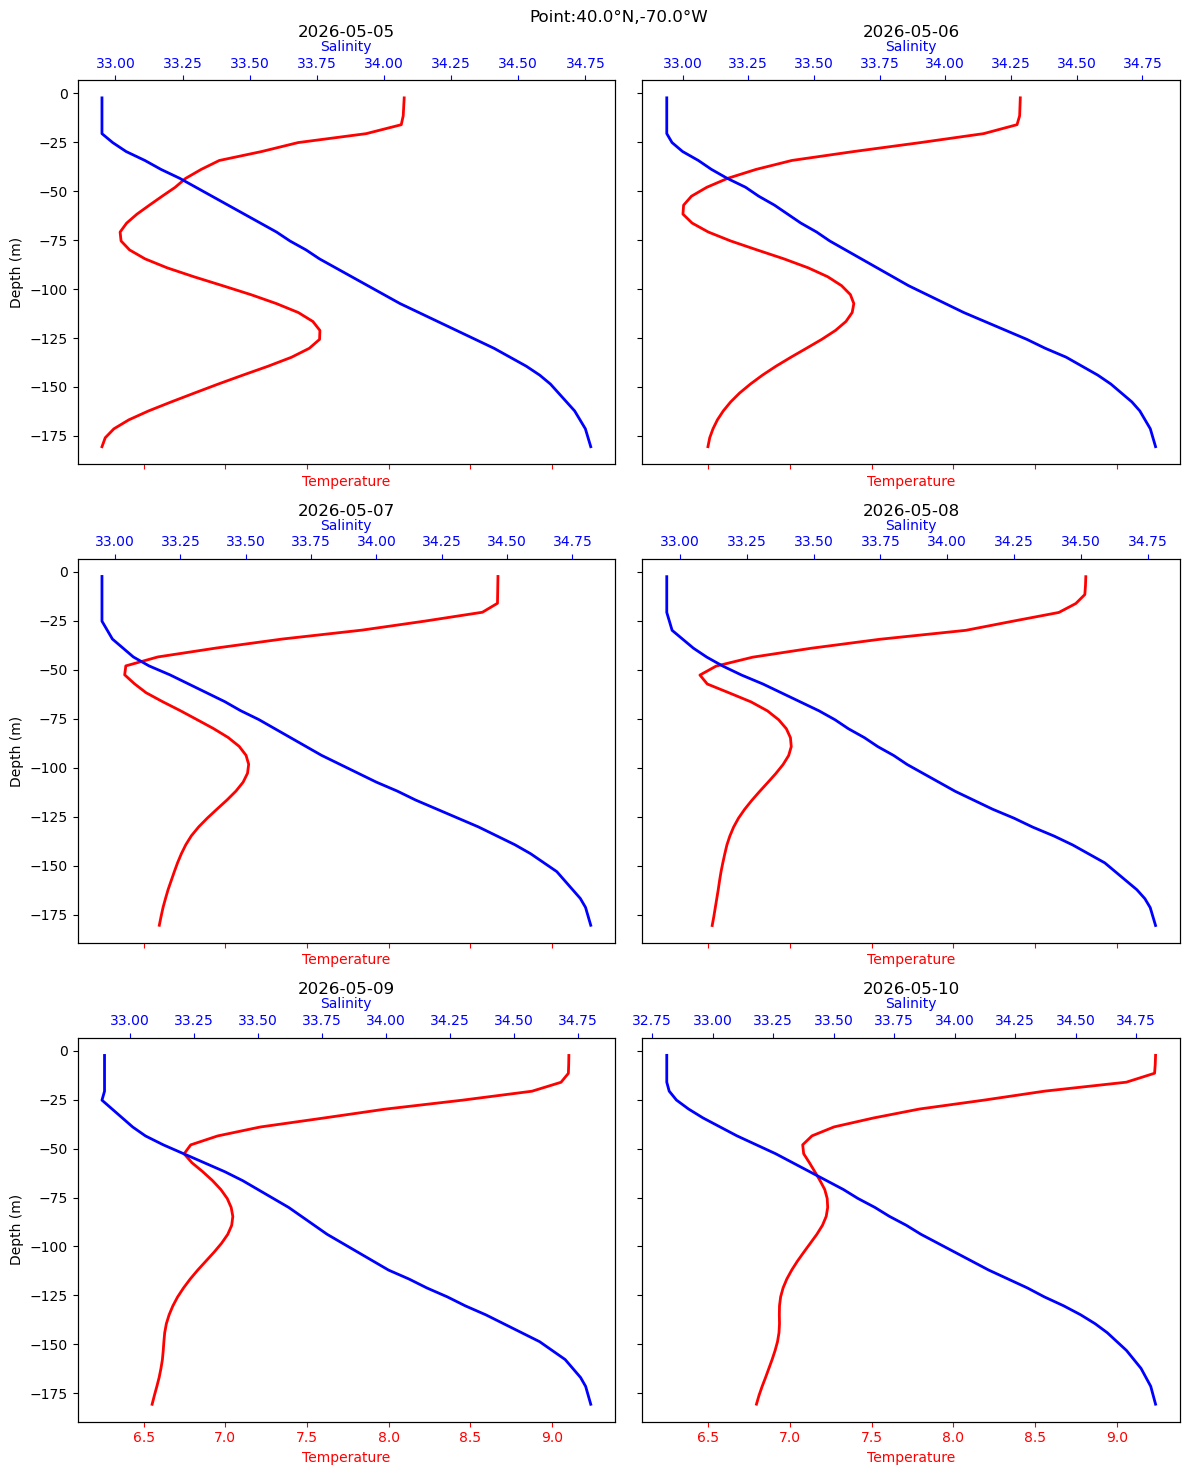

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(12, 15), sharey=True,sharex=True)

axes = axes.flatten()

for i in range(6):
    dynamic_depth = (
        subset_point.s_rho * subset_point.h
        + subset_point.zeta[i].values
    )

    ax1 = axes[i]

    # Temperature
    ax1.plot(np.round(subset_point['temp'][i],3),dynamic_depth,color='r',linewidth=2)

    ax1.set_xlabel('Temperature', color='r')
    ax1.tick_params(axis='x', colors='r')

    # Salinity
    ax2 = ax1.twiny()

    ax2.plot(np.round(subset_point['salt'][i],2),dynamic_depth,color='b',linewidth=2)

    ax2.set_xlabel('Salinity', color='b')
    ax2.tick_params(axis='x', colors='b')

    ax1.set_title(f'{pd.to_datetime(ds.time1[i].values).strftime("%Y-%m-%d")}',pad=0.6)


    # only label y-axis on left column
    if i % 2 == 0:
        ax1.set_ylabel('Depth (m)')

plt.suptitle(f'Point:{target_lat}\u00B0N,{target_lon}\u00B0W',x=0.52);

plt.tight_layout()


In [26]:
plt.figure(figsize=(10, 5))

dynamic_depth = (subset_point['s_rho']*subset_point['h']) #+ subset_point['zeta']

plt.pcolor(subset_point['time1'],dynamic_depth,subset_point['temp'].T, shading ='auto')

cbar = plt.colorbar()

cbar.set_label('Temperature (\u00B0C)')
plt.ylabel('Depth (m)')
plt.xlabel('Date')

plt.title(f'Temperature at {target_lat}\u00B0N,{target_lon}\u00B0W');